# 03 — Mô hình cơ sở

**Mục tiêu.** Dựng ba cái mốc để mọi con số về sau có chỗ mà so, và lấy bằng chứng bằng số cho
**G-2**: *accuracy vô nghĩa ở bài toán này, PR-AUC mới là chỉ số phân biệt được mô hình.*

**Việc tương ứng:** T-16 … T-19 trong [TASKS.md](../TASKS.md).

| Mốc | Là gì | Để làm gì |
|---|---|---|
| Mô hình rỗng | luôn trả "hợp lệ" | cho ra con số accuracy 99,83% — sàn mà mọi mô hình phải vượt |
| Logistic Regression | tuyến tính, **không** xử lý mất cân bằng | mốc tuyến tính (04 §3.2, M1) |
| Decision Tree | `max_depth=6`, **không** xử lý mất cân bằng | mốc phi tuyến đơn giản (M2) |

Cả hai mô hình thật đều chạy ở chiến lược **S1 — không xử lý mất cân bằng**. Đó là chủ ý:
giai đoạn 3 sẽ thêm `class_weight`, undersampling và SMOTE lên đúng hai mô hình này, và phần
chênh lệch so với đây mới là thứ đo được mức đóng góp của từng chiến lược.

**Sản phẩm bàn giao.** `data/test_set.parquet` (tập kiểm thử kèm nhãn thật) và
`reports/baseline_results.csv`.

**Cách chạy.** Kernel sạch, `Run All`. Khoảng 2 phút, phần lớn nằm ở bootstrap.

In [1]:
import sys
import time
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve

from src import plots
from src.config import RANDOM_STATE, REPORTS_DIR, TARGET, TEST_SET_PATH, TEST_SIZE
from src.data import load_prepared, split_data
from src.evaluate import baseline_pr_auc, bootstrap_ci, compute_metrics, predict_scores
from src.features import RAW_REQUIRED_COLUMNS, build_features
from src.modeling import build_pipeline
from src.threshold import NAIVE_THRESHOLD

%matplotlib inline
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 170)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

np.random.seed(RANDOM_STATE)

df, bao_cao = load_prepared()
print()
print(f"Ngưỡng quyết định dùng trong notebook này: τ = {NAIVE_THRESHOLD} "
      "(mặc định, CHƯA tối ưu — việc đó thuộc giai đoạn 5)")

Số dòng        : 284,807
Số cột         : 31
Ô thiếu giá trị: 0
Dòng trùng lặp : 1,081
Gian lận       : 492 (0.173%)
Không phát hiện vấn đề.


Loại 1,081 dòng trùng lặp (0.380%), trong đó 19 mẫu gian lận. Còn lại 283,726 dòng.

Ngưỡng quyết định dùng trong notebook này: τ = 0.5 (mặc định, CHƯA tối ưu — việc đó thuộc giai đoạn 5)


---
## 1. Chia tập phân tầng 80/20 — T-16

Chia **sau** khi đã loại trùng lặp (DS-20, ML-06). Thứ tự ngược lại sẽ để cùng một dòng rơi
vào cả hai tập.

Phân tầng là bắt buộc chứ không phải tuỳ chọn: với 0,167% lớp dương, một lần chia ngẫu nhiên
không phân tầng có thể lệch vài chục mẫu dương giữa hai tập, đủ để làm mọi chỉ số nhảy loạn.

In [2]:
# Chia MỘT lần trên cột thô, rồi mới sinh đặc trưng cho từng nửa. Gọi split_data hai lần
# (một lần as_features=True, một lần False) tuy cho cùng kết quả nhưng không có gì bảo đảm
# điều đó về sau — chia một lần thì không phải tin vào may mắn.
X_train_tho, X_test_tho, y_train, y_test = split_data(df, as_features=False)

X_train = build_features(X_train_tho)
X_test = build_features(X_test_tho)

tom_tat = pd.DataFrame({
    "số dòng": [len(y_train), len(y_test), len(df)],
    "gian lận": [int(y_train.sum()), int(y_test.sum()), int(df[TARGET].sum())],
    "tỷ lệ dương": [y_train.mean(), y_test.mean(), df[TARGET].mean()],
}, index=["tập huấn luyện", "tập kiểm thử", "toàn bộ"])
tom_tat["phần trăm tổng"] = tom_tat["số dòng"] / len(df)
display(tom_tat.style.format({"tỷ lệ dương": "{:.5%}", "phần trăm tổng": "{:.1%}",
                              "số dòng": "{:,}"}))

print(f"Đặc trưng đưa vào mô hình: {X_train.shape[1]} cột (02 §4)")
print(f"Thời gian huấn luyện trải: {X_train_tho['Time'].min():.0f} → "
      f"{X_train_tho['Time'].max():,.0f} giây")

,số dòng,gian lận,tỷ lệ dương,phần trăm tổng
tập huấn luyện,"226,980",378,0.16653%,80.0%
tập kiểm thử,"56,746",95,0.16741%,20.0%
toàn bộ,"283,726",473,0.16671%,100.0%


Đặc trưng đưa vào mô hình: 31 cột (02 §4)
Thời gian huấn luyện trải: 0 → 172,792 giây


In [3]:
# Kiểm tra ngay tại chỗ, không đợi tới T-28
chong_lan = set(X_train_tho.index) & set(X_test_tho.index)
assert not chong_lan, f"{len(chong_lan)} dòng nằm ở cả hai tập"
assert len(y_train) + len(y_test) == len(df), "chia tập làm mất hoặc nhân đôi dòng"
assert int(y_test.sum()) == 95, f"T-16 cần đúng 95 mẫu gian lận, đang có {int(y_test.sum())}"
assert abs(y_test.mean() - df[TARGET].mean()) < 1e-4, "phân tầng không giữ được tỷ lệ lớp"
assert list(X_train.columns) == list(X_test.columns), "hai tập lệch thứ tự cột"

print("[x] không dòng nào nằm ở cả hai tập")
print("[x] tổng số dòng khớp")
print(f"[x] tập kiểm thử có đúng {int(y_test.sum())} mẫu gian lận (T-16)")
print(f"[x] phân tầng giữ đúng tỷ lệ: {y_train.mean():.5%} so với {y_test.mean():.5%}")
print("[x] thứ tự cột hai tập trùng nhau")

[x] không dòng nào nằm ở cả hai tập
[x] tổng số dòng khớp
[x] tập kiểm thử có đúng 95 mẫu gian lận (T-16)
[x] phân tầng giữ đúng tỷ lệ: 0.16653% so với 0.16741%
[x] thứ tự cột hai tập trùng nhau


### 1.1 Lưu `data/test_set.parquet`

Tệp này là dữ liệu tham chiếu lúc chạy, không phải hiện vật huấn luyện: chế độ phát lại
(UI-05) và màn hình hiệu năng (UI-04) đều đọc từ đây ([02 §8](../docs/02-dac-ta-du-lieu.md)).

Lưu **cột thô** chứ không lưu ma trận đặc trưng: phía API phải tự gọi `build_features()` trên
đúng dữ liệu như khi phục vụ thật, nếu không thì ranh giới train/serve mất chỗ để kiểm (DS-04).
Sắp sẵn theo `Time` tăng dần vì chế độ phát lại đọc theo thứ tự đó ([07 §7](../docs/07-thiet-ke-giao-dien.md)).

Cột `risk_score` **chưa có ở bước này** — nó do notebook 08 ghi thêm sau khi chốt mô hình (T-35).

In [4]:
test_set = X_test_tho.assign(**{TARGET: y_test}).sort_values("Time").reset_index(drop=True)

TEST_SET_PATH.parent.mkdir(parents=True, exist_ok=True)
test_set.to_parquet(TEST_SET_PATH, index=False)

doc_lai = pd.read_parquet(TEST_SET_PATH)
assert len(doc_lai) == len(X_test), "số dòng đọc lại không khớp"
assert int(doc_lai[TARGET].sum()) == 95, "số mẫu gian lận đọc lại không khớp"
assert list(doc_lai.columns) == [*RAW_REQUIRED_COLUMNS, TARGET], "lược đồ cột sai"
assert doc_lai.isna().sum().sum() == 0, "có ô thiếu giá trị"
assert doc_lai["Time"].is_monotonic_increasing, "chưa sắp theo Time"

print(f"đã ghi {TEST_SET_PATH.relative_to(ROOT)} "
      f"({TEST_SET_PATH.stat().st_size / 1024**2:.2f} MB)")
print(f"  {len(doc_lai):,} dòng × {doc_lai.shape[1]} cột, {int(doc_lai[TARGET].sum())} gian lận")
print(f"  ngày 1 (Time < 86.400): {int((doc_lai['Time'] < 86_400).sum()):,} dòng")
print(f"  ngày 2:                 {int((doc_lai['Time'] >= 86_400).sum()):,} dòng "
      "→ nguồn cho chế độ phát lại")
print()
print("T-16 đạt: chia phân tầng 80/20, tập kiểm thử có đúng 95 mẫu gian lận, "
      "test_set.parquet đọc lại được.")

đã ghi data\test_set.parquet (15.42 MB)
  56,746 dòng × 31 cột, 95 gian lận
  ngày 1 (Time < 86.400): 28,997 dòng
  ngày 2:                 27,749 dòng → nguồn cho chế độ phát lại

T-16 đạt: chia phân tầng 80/20, tập kiểm thử có đúng 95 mẫu gian lận, test_set.parquet đọc lại được.


---
## 2. Mô hình rỗng — T-17

Mô hình trả "hợp lệ" cho **mọi** giao dịch. Không học gì, không nhìn một đặc trưng nào.

Đây không phải trò đùa mà là phép đo cần thiết: nó cho biết một chỉ số bằng bao nhiêu khi mô
hình hoàn toàn vô dụng. Chỉ số nào mà mô hình vô dụng đã đạt điểm cao thì chỉ số đó không dùng
để đánh giá được.

In [5]:
mo_hinh_rong = DummyClassifier(strategy="constant", constant=0).fit(X_train, y_train)
diem_rong = predict_scores(mo_hinh_rong, X_test)

met_rong = compute_metrics(y_test, diem_rong, NAIVE_THRESHOLD, "mô hình rỗng")
acc_rong = (met_rong["tp"] + met_rong["tn"]) / len(y_test)

print(f"Accuracy : {acc_rong:.6f}  →  {acc_rong:.2%}")
print(f"PR-AUC   : {met_rong['pr_auc']:.5f}   (đường cơ sở = tỷ lệ lớp dương "
      f"{baseline_pr_auc(y_test):.5f})")
print(f"ROC-AUC  : {met_rong['roc_auc']:.4f}")
print(f"Precision: {met_rong['precision']:.4f}     Recall: {met_rong['recall']:.4f}")
print(f"TP {int(met_rong['tp'])}   FP {int(met_rong['fp'])}   "
      f"FN {int(met_rong['fn'])}   TN {int(met_rong['tn']):,}")
print()
print(f"Mô hình này bỏ lọt TOÀN BỘ {int(met_rong['fn'])} vụ gian lận trong tập kiểm thử.")

Accuracy : 0.998326  →  99.83%
PR-AUC   : 0.00167   (đường cơ sở = tỷ lệ lớp dương 0.00167)
ROC-AUC  : 0.5000
Precision: 0.0000     Recall: 0.0000
TP 0   FP 0   FN 95   TN 56,651

Mô hình này bỏ lọt TOÀN BỘ 95 vụ gian lận trong tập kiểm thử.


**Nhận xét — đây là con số trung tâm của G-2.**

**Accuracy = 99,83%.** Đạt được mà không cần một dòng học máy nào, không nhìn một đặc trưng
nào, và bỏ lọt **toàn bộ 95 vụ gian lận**. Với chi phí giả định 122,21 USD cho mỗi vụ bỏ lọt
([04 §6.2](../docs/04-thiet-ke-mo-hinh-ml.md)), mô hình "xuất sắc 99,83%" này gây thiệt hại
khoảng **11.610 USD** chỉ riêng trên tập kiểm thử.

Hai chỉ số còn lại thì không bị lừa:

- **PR-AUC = 0,00167**, đúng bằng tỷ lệ lớp dương. Đây là định nghĩa của đường cơ sở PR-AUC:
  điểm mà một bộ xếp hạng ngẫu nhiên đạt được. Mọi hình PR về sau đều phải vẽ vạch này (T-21).
- **ROC-AUC = 0,5000**, đúng bằng mức tung đồng xu.

Kết luận đưa vào báo cáo: **accuracy bị loại khỏi mọi bảng kết quả chính**. Nó chỉ còn xuất
hiện đúng một lần, ở bảng §4 dưới đây, với tư cách tang vật.

---
## 3. Hai mô hình cơ sở — T-18

Cả hai dựng qua `build_pipeline(..., strategy="none")`, nên chúng có **đúng** cấu trúc pipeline
với 20 tổ hợp của giai đoạn 3: `preprocess → clf`. Nhờ vậy phần chênh lệch đo được sau này là
chênh lệch do chiến lược xử lý mất cân bằng, không lẫn khác biệt về cách tiền xử lý.

`RobustScaler` cho `Amount` nằm **trong** pipeline (ML-04): nó chỉ học trung vị và IQR của tập
huấn luyện. Fit scaler trên toàn bộ dữ liệu trước khi chia tập là dạng rò rỉ kinh điển.

In [6]:
cau_hinh = {
    "logistic_regression": "max_iter=1000, solver='liblinear'",
    "decision_tree": "max_depth=6",
}

mo_hinh = {"mô hình rỗng": mo_hinh_rong}
diem = {"mô hình rỗng": diem_rong}
thoi_gian = {"mô hình rỗng": 0.0}

for ten in ("logistic_regression", "decision_tree"):
    pipeline = build_pipeline(ten, strategy="none", random_state=RANDOM_STATE)
    bat_dau = time.perf_counter()
    pipeline.fit(X_train, y_train)
    thoi_gian[ten] = time.perf_counter() - bat_dau

    mo_hinh[ten] = pipeline
    diem[ten] = predict_scores(pipeline, X_test)
    print(f"{ten:20s} ({cau_hinh[ten]:38s}) huấn luyện {thoi_gian[ten]:5.2f}s  "
          f"→ {len(np.unique(diem[ten])):,} điểm rủi ro khác nhau")

print()
print("Các bước trong pipeline:", [ten for ten, _ in mo_hinh["decision_tree"].steps])

logistic_regression  (max_iter=1000, solver='liblinear'     ) huấn luyện  3.37s  → 56,537 điểm rủi ro khác nhau


decision_tree        (max_depth=6                           ) huấn luyện  5.95s  → 8 điểm rủi ro khác nhau

Các bước trong pipeline: ['preprocess', 'clf']


---
## 4. Bảng đối chiếu ba mô hình — T-19

Bốn chỉ số cạnh nhau trên cùng một tập kiểm thử, cùng một ngưỡng τ = 0,5.

In [7]:
hang = []
for ten, s in diem.items():
    met = compute_metrics(y_test, s, NAIVE_THRESHOLD, ten)
    hang.append({
        "mô hình": ten,
        "accuracy": (met["tp"] + met["tn"]) / len(y_test),
        "PR-AUC": met["pr_auc"],
        "ROC-AUC": met["roc_auc"],
        "precision": met["precision"],
        "recall": met["recall"],
        "F1": met["f1"],
        "TP": int(met["tp"]), "FP": int(met["fp"]),
        "FN": int(met["fn"]), "TN": int(met["tn"]),
        "giây huấn luyện": thoi_gian[ten],
    })

bang_moc = pd.DataFrame(hang).set_index("mô hình")
display(bang_moc.style.format({
    "accuracy": "{:.4%}", "PR-AUC": "{:.4f}", "ROC-AUC": "{:.4f}",
    "precision": "{:.4f}", "recall": "{:.4f}", "F1": "{:.4f}",
    "TN": "{:,}", "giây huấn luyện": "{:.2f}",
}).background_gradient(subset=["PR-AUC"], cmap="Greens"))

,accuracy,PR-AUC,ROC-AUC,precision,recall,F1,TP,FP,FN,TN,giây huấn luyện
mô hình,,,,,,,,,,,
mô hình rỗng,99.8326%,0.0017,0.5000,0.0000,0.0000,0.0000,0,0,95,"56,651",0.00
logistic_regression,99.9154%,0.6961,0.9577,0.8507,0.6000,0.7037,57,10,38,"56,641",3.37
decision_tree,99.9383%,0.6275,0.8746,0.8947,0.7158,0.7953,68,8,27,"56,643",5.95


In [8]:
dai_acc = bang_moc["accuracy"].max() - bang_moc["accuracy"].min()
ty_le_pr = bang_moc["PR-AUC"].max() / bang_moc["PR-AUC"].min()

print("Sức phân biệt của từng chỉ số trên ba mô hình")
print("=" * 66)
print(f"accuracy: {bang_moc['accuracy'].min():.4%} → {bang_moc['accuracy'].max():.4%}   "
      f"chênh {dai_acc * 100:.4f} điểm phần trăm")
print(f"PR-AUC  : {bang_moc['PR-AUC'].min():.5f} → {bang_moc['PR-AUC'].max():.5f}   "
      f"chênh {ty_le_pr:.0f} LẦN")
print(f"ROC-AUC : {bang_moc['ROC-AUC'].min():.4f} → {bang_moc['ROC-AUC'].max():.4f}")
print()

acc_lr = bang_moc.loc["logistic_regression", "accuracy"]
acc_dt = bang_moc.loc["decision_tree", "accuracy"]
pr_lr = bang_moc.loc["logistic_regression", "PR-AUC"]
pr_dt = bang_moc.loc["decision_tree", "PR-AUC"]

print("Và tệ hơn cả việc không phân biệt được — accuracy XẾP HẠNG NGƯỢC:")
print(f"  accuracy: decision_tree {acc_dt:.4%} > logistic_regression {acc_lr:.4%}")
print(f"  PR-AUC  : decision_tree {pr_dt:.4f}   < logistic_regression {pr_lr:.4f}")
print(f"  → theo accuracy thì cây thắng, theo PR-AUC thì hồi quy thắng.")

Sức phân biệt của từng chỉ số trên ba mô hình
accuracy: 99.8326% → 99.9383%   chênh 0.1057 điểm phần trăm
PR-AUC  : 0.00167 → 0.69610   chênh 416 LẦN
ROC-AUC : 0.5000 → 0.9577

Và tệ hơn cả việc không phân biệt được — accuracy XẾP HẠNG NGƯỢC:
  accuracy: decision_tree 99.9383% > logistic_regression 99.9154%
  PR-AUC  : decision_tree 0.6275   < logistic_regression 0.6961
  → theo accuracy thì cây thắng, theo PR-AUC thì hồi quy thắng.


**Nhận xét — bằng chứng cho G-2.**

| chỉ số | dải giá trị trên ba mô hình | phân biệt được không? |
|---|---|---|
| accuracy | 99,8326% → 99,9383% | **không** — chênh 0,11 điểm phần trăm |
| ROC-AUC | 0,5000 → 0,9577 | một phần — nhưng 0,87 và 0,96 nghe đều "rất tốt" |
| **PR-AUC** | **0,00167 → 0,6961** | **có** — chênh **416 lần** |

Ba điều đọc ra từ bảng:

1. **Accuracy không phân biệt được ba mô hình.** Cả ba đều "trên 99,8%". Khoảng cách giữa mô
   hình bỏ lọt 100% số vụ và mô hình bắt được 60% chỉ là **0,08 điểm phần trăm**. Một biểu đồ
   cột accuracy của ba mô hình này là ba cột cao bằng nhau.

2. **Accuracy còn xếp hạng ngược.** Decision Tree có accuracy **cao hơn** Logistic Regression
   (99,9383% so với 99,9154%) nhưng PR-AUC **thấp hơn** (0,6275 so với 0,6961). Chọn mô hình
   theo accuracy ở đây không chỉ là chọn mù — nó dẫn tới chọn sai. Đây là lý do ML-03 bắt buộc
   `scoring='average_precision'` khi tinh chỉnh.

3. **ROC-AUC tâng bốc.** Logistic Regression đạt ROC-AUC 0,9577 — con số nghe như một mô hình
   gần hoàn hảo — trong khi PR-AUC chỉ 0,6961 và nó bỏ lọt 38 trong 95 vụ. Nguyên nhân ở mẫu
   số: tỷ lệ dương tính giả của ROC là `FP/(FP+TN)` với `TN ≈ 56.651` gần như không đổi, nên
   FP nhảy từ 10 lên 1.000 mà trục hoành của ROC gần như đứng yên. Precision `TP/(TP+FP)` thì
   sụp ngay. **ROC-AUC vẫn báo cáo kèm để đối chiếu, nhưng không bao giờ là chỉ số quyết định**
   (04 §5.2).

Về bản thân hai mô hình cơ sở: ở τ = 0,5 chúng bắt được 57 và 68 trong 95 vụ, tức **recall
0,60 và 0,72**, chưa đạt AC-M2 (≥ 0,75). Điều đó đúng như dự kiến — đây là mốc, chưa xử lý mất
cân bằng và chưa chọn ngưỡng.

*Vì sao mô hình rỗng không có đường cong riêng trong hình dưới.* Nó gán **cùng một điểm rủi ro
cho mọi giao dịch**, nên không xếp hạng được gì; đường PR và ROC của nó suy biến thành một đoạn
thẳng, vẽ lên sẽ trông như một mô hình tàm tạm. Chỗ đúng của nó chính là **hai đường tham chiếu
đứt nét**: đường chéo trong ô ROC (AUC 0,500) và đường cơ sở 0,00167 trong ô PR.

WindowsPath('D:/WorkSpace/AI_Project/fraud-detection/reports/figures/03_roc_vs_pr.png')

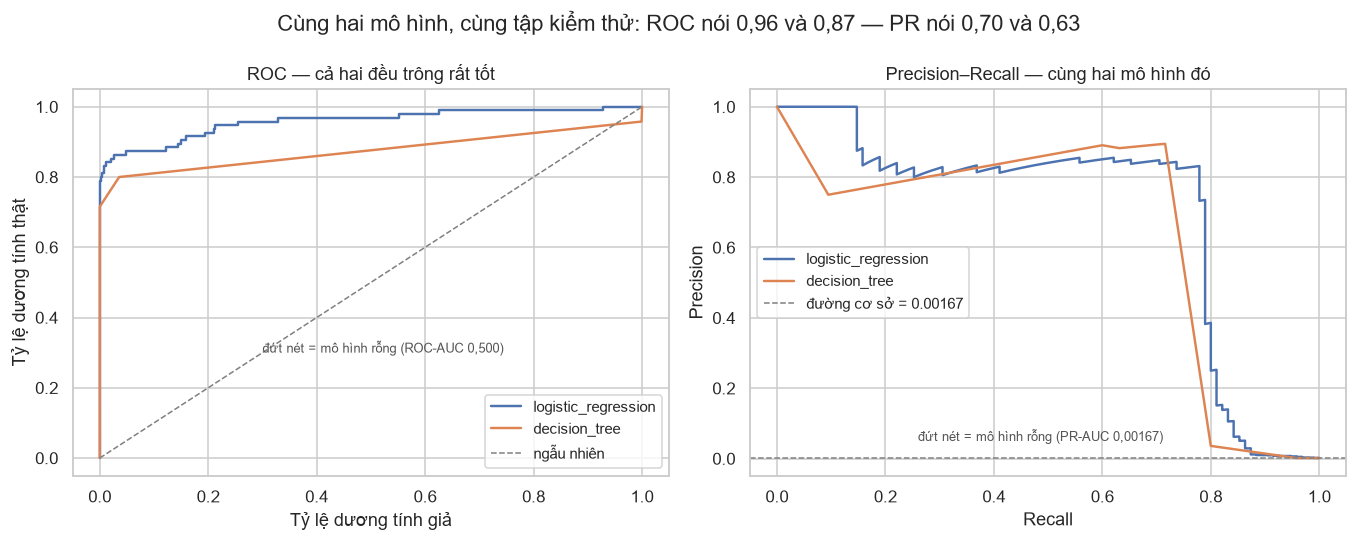

In [9]:
# Chỉ vẽ hai mô hình THẬT. Mô hình rỗng gán cho mọi giao dịch cùng một điểm rủi ro nên
# đường PR và ROC của nó suy biến thành một đoạn thẳng — vẽ lên sẽ trông như một mô hình
# tàm tạm, trong khi nó không xếp hạng được gì cả. Nó đã có mặt đúng chỗ của nó rồi:
# chính là hai đường tham chiếu đứt nét trong mỗi ô.
diem_that = {ten: s for ten, s in diem.items() if ten != "mô hình rỗng"}

fig, truc = plt.subplots(1, 2, figsize=(12.5, 5))

plots.plot_roc_curves(diem_that, y_true=y_test, ax=truc[0])
truc[0].set_title("ROC — cả hai đều trông rất tốt")
truc[0].annotate("đứt nét = mô hình rỗng (ROC-AUC 0,500)", (0.30, 0.30),
                 fontsize=8.5, color="#555555")

plots.plot_pr_curves(diem_that, y_true=y_test, ax=truc[1])
truc[1].set_title("Precision–Recall — cùng hai mô hình đó")
truc[1].annotate("đứt nét = mô hình rỗng (PR-AUC 0,00167)", (0.26, 0.05),
                 fontsize=8.5, color="#555555")

fig.suptitle("Cùng hai mô hình, cùng tập kiểm thử: ROC nói 0,96 và 0,87 — PR nói 0,70 và 0,63")
fig.tight_layout()
plots.save_fig(fig, "03_roc_vs_pr.png")

WindowsPath('D:/WorkSpace/AI_Project/fraud-detection/reports/figures/03_accuracy_vs_prauc.png')

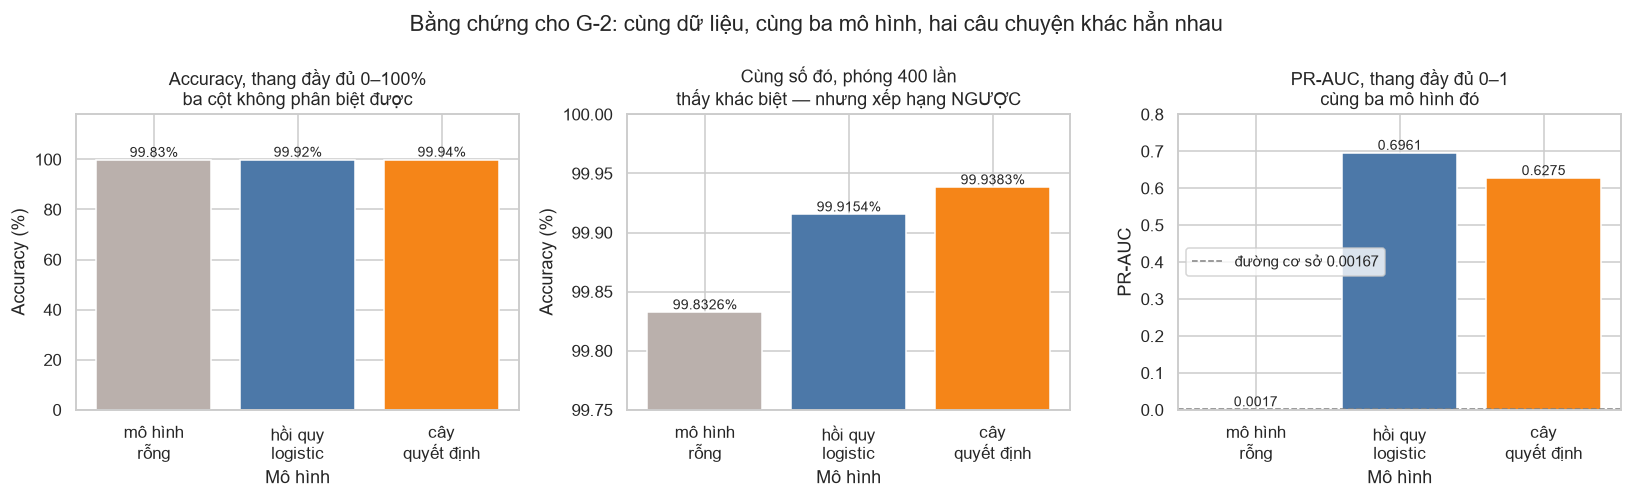

In [10]:
fig, truc = plt.subplots(1, 3, figsize=(15, 4.6))
ten_ngan = ["mô hình\nrỗng", "hồi quy\nlogistic", "cây\nquyết định"]
mau_cot = ["#BAB0AC", "#4C78A8", "#F58518"]

# Ô 1 — accuracy ở thang đầy đủ, đúng cách một biểu đồ cột phải vẽ
truc[0].bar(ten_ngan, bang_moc["accuracy"] * 100, color=mau_cot)
truc[0].set_ylim(0, 118)
truc[0].set_yticks(range(0, 101, 20))
truc[0].set_xlabel("Mô hình")
truc[0].set_ylabel("Accuracy (%)")
truc[0].set_title("Accuracy, thang đầy đủ 0–100%\nba cột không phân biệt được")
for i, v in enumerate(bang_moc["accuracy"]):
    truc[0].text(i, v * 100, f"{v:.2%}", ha="center", va="bottom", fontsize=9)

# Ô 2 — cũng con số đó, phóng gần 400 lần thì mới thấy chênh — và thấy nó xếp ngược
truc[1].bar(ten_ngan, bang_moc["accuracy"] * 100, color=mau_cot)
truc[1].set_ylim(99.75, 100.0)
truc[1].set_xlabel("Mô hình")
truc[1].set_ylabel("Accuracy (%)")
truc[1].set_title("Cùng số đó, phóng 400 lần\nthấy khác biệt — nhưng xếp hạng NGƯỢC")
for i, v in enumerate(bang_moc["accuracy"]):
    truc[1].text(i, v * 100, f"{v:.4%}", ha="center", va="bottom", fontsize=9)

# Ô 3 — PR-AUC, cũng thang đầy đủ
truc[2].bar(ten_ngan, bang_moc["PR-AUC"], color=mau_cot)
truc[2].axhline(baseline_pr_auc(y_test), ls="--", c="grey", lw=1,
                label=f"đường cơ sở {baseline_pr_auc(y_test):.5f}")
truc[2].set_ylim(0, 0.8)
truc[2].set_xlabel("Mô hình")
truc[2].set_ylabel("PR-AUC")
truc[2].set_title("PR-AUC, thang đầy đủ 0–1\ncùng ba mô hình đó")
truc[2].legend(fontsize="small", loc="center left")
for i, v in enumerate(bang_moc["PR-AUC"]):
    truc[2].text(i, v, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Bằng chứng cho G-2: cùng dữ liệu, cùng ba mô hình, hai câu chuyện khác hẳn nhau")
fig.tight_layout()
plots.save_fig(fig, "03_accuracy_vs_prauc.png")

WindowsPath('D:/WorkSpace/AI_Project/fraud-detection/reports/figures/03_confusion_baselines.png')

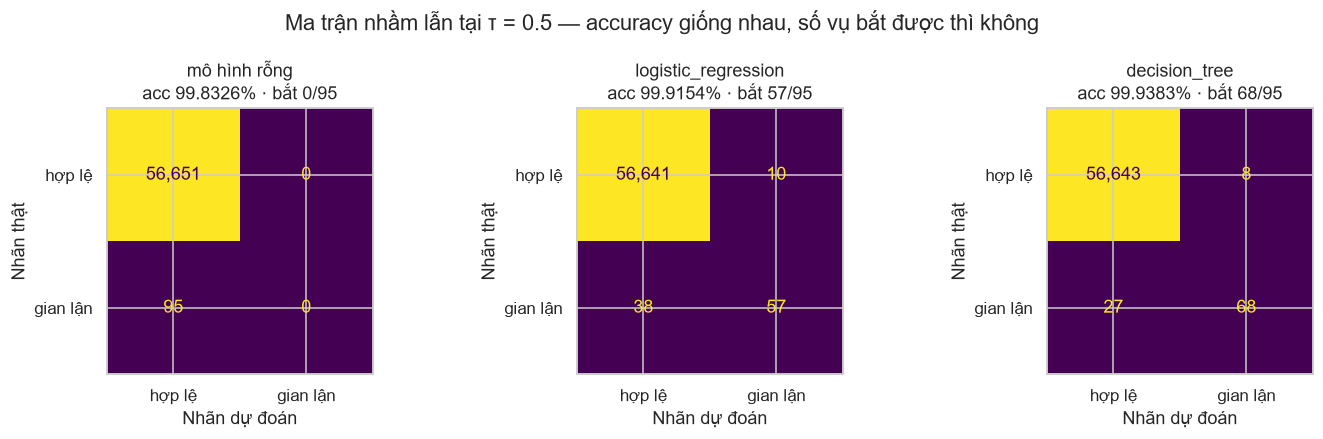

In [11]:
fig, truc = plt.subplots(1, 3, figsize=(13, 4))
for ax, (ten, s) in zip(truc, diem.items()):
    plots.plot_confusion(y_test, (s >= NAIVE_THRESHOLD).astype(int), ax=ax)
    met = bang_moc.loc[ten]
    ax.set_title(f"{ten}\nacc {met['accuracy']:.4%} · bắt {int(met['TP'])}/95")

fig.suptitle(f"Ma trận nhầm lẫn tại τ = {NAIVE_THRESHOLD} — accuracy giống nhau, "
             "số vụ bắt được thì không")
fig.tight_layout()
plots.save_fig(fig, "03_confusion_baselines.png")

---
## 5. Khoảng tin cậy: có được nói mô hình nào tốt hơn không?

Tập kiểm thử chỉ có 95 mẫu dương. Trước khi tuyên bố Logistic Regression tốt hơn Decision Tree
vì 0,696 > 0,628, phải hỏi: chênh lệch đó có lớn hơn dao động mẫu không?

[04 §5.4](../docs/04-thiet-ke-mo-hinh-ml.md) chỉ định cách làm: **bootstrap hiệu PR-AUC, xét
khoảng tin cậy có chứa 0 hay không**. Bootstrap phải **phân tầng** — lấy mẫu lại riêng trong
từng lớp — vì bootstrap thường trên dữ liệu 0,17% dương có thể sinh ra mẫu không chứa vụ gian
lận nào.

In [12]:
ktc = {}
for ten, s in diem.items():
    ktc[ten] = bootstrap_ci(y_test, s, "pr_auc", n_boot=1000, random_state=RANDOM_STATE)
    print(f"{ten:20s} PR-AUC = {ktc[ten]['value']:.4f} "
          f"[{ktc[ten]['ci_low']:.4f} – {ktc[ten]['ci_high']:.4f}]")

print()
chong_lan_ci = (ktc["logistic_regression"]["ci_low"] <= ktc["decision_tree"]["ci_high"]
                and ktc["decision_tree"]["ci_low"] <= ktc["logistic_regression"]["ci_high"])
print(f"Hai khoảng tin cậy chồng lấn nhau: {chong_lan_ci}")

mô hình rỗng         PR-AUC = 0.0017 [0.0017 – 0.0017]


logistic_regression  PR-AUC = 0.6961 [0.5975 – 0.7909]


decision_tree        PR-AUC = 0.6275 [0.5215 – 0.7369]

Hai khoảng tin cậy chồng lấn nhau: True


In [13]:
# Bootstrap hiệu PR-AUC theo CẶP: mỗi lần lặp dùng CÙNG một mẫu cho cả hai mô hình.
# So hai khoảng tin cậy riêng lẻ là phép kiểm bảo thủ hơn mức cần thiết, vì nó bỏ qua
# tương quan giữa hai mô hình trên cùng các giao dịch.
y_mang = y_test.to_numpy()
chi_so_duong = np.flatnonzero(y_mang == 1)
chi_so_am = np.flatnonzero(y_mang == 0)
rng = np.random.default_rng(RANDOM_STATE)

hieu = np.empty(1000)
for i in range(1000):
    idx = np.concatenate([
        rng.choice(chi_so_duong, chi_so_duong.size, replace=True),
        rng.choice(chi_so_am, chi_so_am.size, replace=True),
    ])
    hieu[i] = (average_precision_score(y_mang[idx], diem["logistic_regression"][idx])
               - average_precision_score(y_mang[idx], diem["decision_tree"][idx]))

thap, cao = np.quantile(hieu, [0.025, 0.975])
quan_sat = ktc["logistic_regression"]["value"] - ktc["decision_tree"]["value"]

print(f"Hiệu PR-AUC (hồi quy − cây) = {quan_sat:+.4f}")
print(f"KTC 95% của hiệu            = [{thap:+.4f}, {cao:+.4f}]")
print(f"Khoảng tin cậy chứa 0       = {thap < 0 < cao}")
print(f"Tỷ lệ lần lặp hồi quy thắng = {(hieu > 0).mean():.1%}")
print()
if thap < 0 < cao:
    print("→ KHÔNG được kết luận mô hình nào tốt hơn. Chênh lệch nằm trong dao động mẫu.")
else:
    print("→ Chênh lệch vượt dao động mẫu.")

Hiệu PR-AUC (hồi quy − cây) = +0.0686
KTC 95% của hiệu            = [-0.0312, +0.1575]
Khoảng tin cậy chứa 0       = True
Tỷ lệ lần lặp hồi quy thắng = 92.0%

→ KHÔNG được kết luận mô hình nào tốt hơn. Chênh lệch nằm trong dao động mẫu.


**Nhận xét.** Hai khoảng tin cậy **chồng lấn nhiều**: `0,696 [0,598 – 0,791]` so với
`0,628 [0,522 – 0,737]`. Phép kiểm chặt hơn — bootstrap hiệu theo cặp — cho
`+0,069 [−0,031, +0,158]`, và **khoảng này chứa 0**.

**Kết luận bắt buộc: chưa được nói Logistic Regression tốt hơn Decision Tree.** Hồi quy thắng
trong 92% số lần lặp, đủ để gọi là "có xu hướng nhỉnh hơn", nhưng không đủ để tuyên bố. Với 95
mẫu dương, một khoảng tin cậy rộng 0,19 là điều phải chấp nhận, không phải lỗi cần giấu.

Đây chính là điều [04 §5.3](../docs/04-thiet-ke-mo-hinh-ml.md) gọi là điểm phân biệt báo cáo
nghiêm túc với báo cáo hời hợt, và là lý do AC-M6 bắt buộc **mọi** chỉ số chính đi kèm khoảng
tin cậy. Quy tắc này sẽ được áp lại nguyên vẹn cho bảng 20 tổ hợp ở giai đoạn 3 — ở đó nhiều
cấu hình sẽ chồng lấn nhau và không được xếp hạng như thể chúng khác biệt thật.

---
## 6. Vì sao cây thua ở PR-AUC dù thắng ở τ = 0,5?

Ở τ = 0,5, Decision Tree **tốt hơn trên cả hai chỉ số**: bắt 68/95 so với 57/95, và precision
0,895 so với 0,851. Vậy mà PR-AUC của nó lại thấp hơn. Đây không phải nghịch lý — nó lộ ra một
tính chất của cây rất quan trọng cho giai đoạn 5.

,số điểm rủi ro khác nhau,số điểm trên đường PR
mô hình rỗng,1,2
logistic_regression,56537,56538
decision_tree,8,9


Toàn bộ 8 điểm rủi ro mà cây có thể sinh ra:
  [0.000e+00 2.000e-04 2.100e-03 5.000e-01 9.388e-01 9.655e-01 9.709e-01
 1.000e+00]

Hồi quy logistic sinh 56,537 giá trị khác nhau → ngưỡng có thể đặt ở gần như bất kỳ đâu.


WindowsPath('D:/WorkSpace/AI_Project/fraud-detection/reports/figures/03_score_granularity.png')

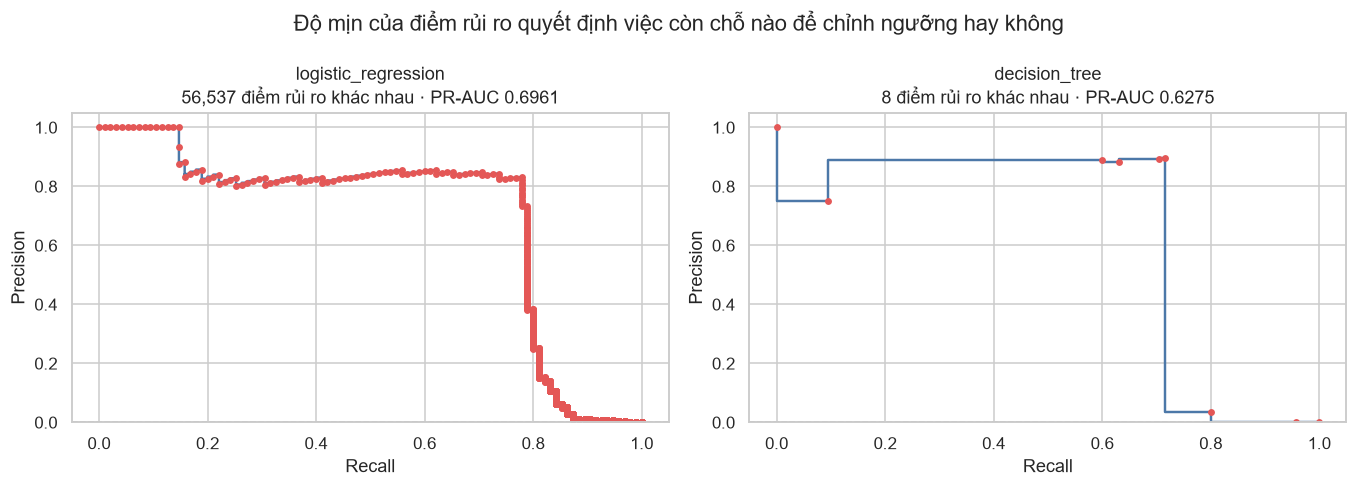

In [14]:
do_min = pd.DataFrame({
    "số điểm rủi ro khác nhau": {ten: len(np.unique(s)) for ten, s in diem.items()},
    "số điểm trên đường PR": {ten: len(precision_recall_curve(y_test, s)[0])
                              for ten, s in diem.items()},
})
display(do_min)

diem_cay = np.unique(diem["decision_tree"])
print(f"Toàn bộ {len(diem_cay)} điểm rủi ro mà cây có thể sinh ra:")
print(" ", np.round(diem_cay, 4))
print()
print(f"Hồi quy logistic sinh {len(np.unique(diem['logistic_regression'])):,} giá trị khác nhau "
      "→ ngưỡng có thể đặt ở gần như bất kỳ đâu.")

fig, truc = plt.subplots(1, 2, figsize=(12.5, 4.5))
for ax, ten in zip(truc, ("logistic_regression", "decision_tree")):
    precision, recall, _ = precision_recall_curve(y_test, diem[ten])
    ax.step(recall, precision, where="post", lw=1.6, color=plots.CLASS_PALETTE[0])
    ax.plot(recall, precision, "o", ms=3.5, color=plots.CLASS_PALETTE[1])
    ax.axhline(baseline_pr_auc(y_test), ls="--", c="grey", lw=1)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"{ten}\n{len(np.unique(diem[ten])):,} điểm rủi ro khác nhau "
                 f"· PR-AUC {ktc[ten]['value']:.4f}")

fig.suptitle("Độ mịn của điểm rủi ro quyết định việc còn chỗ nào để chỉnh ngưỡng hay không")
fig.tight_layout()
plots.save_fig(fig, "03_score_granularity.png")

**Nhận xét.** Nguyên nhân nằm ở **độ mịn của điểm rủi ro**.

`max_depth=6` cho cây tối đa 64 lá, nhưng trên dữ liệu này chỉ **8 giá trị xác suất khác nhau**
thực sự xuất hiện. Đường PR của cây vì thế là một cầu thang **9 điểm**; phần lớn diện tích dưới
đường cong là nội suy giữa vài bậc thô. Logistic Regression sinh **56.537** giá trị khác nhau,
đường PR của nó là một đường liên tục thật sự.

Hai chỉ số đang trả lời hai câu hỏi khác nhau:

- **Precision/recall tại τ = 0,5** hỏi: *tại đúng một ngưỡng này, mô hình làm được gì?* Cây
  thắng, vì tình cờ một bậc thang của nó rơi vào chỗ đẹp.
- **PR-AUC** hỏi: *mô hình xếp hạng rủi ro tốt đến đâu, xét trên mọi ngưỡng?* Hồi quy thắng, vì
  nó xếp hạng được toàn bộ 56.746 giao dịch chứ không gộp chúng vào 8 nhóm.

**Hệ quả cho giai đoạn 5 — đây mới là điều đáng mang đi.** Toàn bộ phần ngưỡng và chi phí
(T-29 … T-31) đứng trên giả định rằng hạ ngưỡng từ 0,5 xuống τ\* sẽ bắt thêm được một số vụ.
Với một mô hình chỉ phát ra 8 điểm rủi ro, **không có τ\* nào để tìm**: kéo thanh trượt đi
đâu trong khoảng giữa hai bậc cũng cho y hệt một kết quả. Đó là lý do mô hình cuối cùng phải
thuộc họ ensemble — hàng trăm cây cộng lại mới cho điểm rủi ro đủ mịn để tối ưu ngưỡng có ý
nghĩa (04 §3.2).

Nói cách khác: **PR-AUC không chỉ đo mô hình hôm nay tốt đến đâu, nó còn đo mô hình đó còn
bao nhiêu chỗ để cải thiện bằng cách chọn ngưỡng.**

---
## 7. Lưu kết quả và kiểm tra điều kiện hoàn thành

In [15]:
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
duong_dan_csv = REPORTS_DIR / "baseline_results.csv"

bang_xuat = bang_moc.copy()
for ten in bang_xuat.index:
    bang_xuat.loc[ten, "pr_auc_ci_low"] = ktc[ten]["ci_low"]
    bang_xuat.loc[ten, "pr_auc_ci_high"] = ktc[ten]["ci_high"]
bang_xuat["threshold"] = NAIVE_THRESHOLD
bang_xuat["n_test"] = len(y_test)
bang_xuat["n_fraud_test"] = int(y_test.sum())
bang_xuat.to_csv(duong_dan_csv, encoding="utf-8")

print(f"đã ghi {duong_dan_csv.relative_to(ROOT)} ({duong_dan_csv.stat().st_size / 1024:.1f} KB)")
display(pd.read_csv(duong_dan_csv, index_col=0)[
    ["accuracy", "PR-AUC", "pr_auc_ci_low", "pr_auc_ci_high", "recall", "precision"]].round(4))

đã ghi reports\baseline_results.csv (0.7 KB)


,accuracy,PR-AUC,pr_auc_ci_low,pr_auc_ci_high,recall,precision
mô hình,,,,,,
mô hình rỗng,0.9983,0.0017,0.0017,0.0017,0.0000,0.0000
logistic_regression,0.9992,0.6961,0.5975,0.7909,0.6000,0.8507
decision_tree,0.9994,0.6275,0.5215,0.7369,0.7158,0.8947


In [16]:
print("Kiểm tra điều kiện hoàn thành — giai đoạn 2")
print("=" * 70)

kiem = {
    "T-16 · chia phân tầng 80/20": abs(len(y_test) / len(df) - TEST_SIZE) < 0.01,
    "T-16 · tập kiểm thử có đúng 95 mẫu gian lận": int(y_test.sum()) == 95,
    "T-16 · data/test_set.parquet tồn tại và đọc lại được": TEST_SET_PATH.exists(),
    "T-17 · mô hình rỗng cho accuracy ≈ 99,83%": round(acc_rong, 4) == 0.9983,
    "T-17 · mô hình rỗng bỏ lọt toàn bộ mẫu dương": int(met_rong["fn"]) == int(y_test.sum()),
    "T-18 · có Logistic Regression, không xử lý mất cân bằng": (
        "logistic_regression" in mo_hinh
        and "resample" not in dict(mo_hinh["logistic_regression"].steps)),
    "T-18 · có Decision Tree, không xử lý mất cân bằng": (
        "decision_tree" in mo_hinh
        and "resample" not in dict(mo_hinh["decision_tree"].steps)),
    "T-19 · bảng có đủ accuracy / PR-AUC / recall / precision": all(
        c in bang_moc.columns for c in ("accuracy", "PR-AUC", "recall", "precision")),
    "T-19 · accuracy KHÔNG phân biệt được ba mô hình (chênh < 1 điểm %)": dai_acc < 0.01,
    "T-19 · PR-AUC thì CÓ (chênh trên 10 lần)": ty_le_pr > 10,
}
for muc, dat in kiem.items():
    print(f"  [{'x' if dat else ' '}] {muc}")

assert all(kiem.values()), "giai đoạn 2 chưa đạt đủ điều kiện"

hinh = sorted(p.name for p in (REPORTS_DIR / "figures").glob("03_*.png"))
print()
print(f"Hình sinh ra ({len(hinh)}):", ", ".join(hinh))
assert len(hinh) == 4

print()
print("T-16, T-17, T-18, T-19 — đạt.")

Kiểm tra điều kiện hoàn thành — giai đoạn 2
  [x] T-16 · chia phân tầng 80/20
  [x] T-16 · tập kiểm thử có đúng 95 mẫu gian lận
  [x] T-16 · data/test_set.parquet tồn tại và đọc lại được
  [x] T-17 · mô hình rỗng cho accuracy ≈ 99,83%
  [x] T-17 · mô hình rỗng bỏ lọt toàn bộ mẫu dương
  [x] T-18 · có Logistic Regression, không xử lý mất cân bằng
  [x] T-18 · có Decision Tree, không xử lý mất cân bằng
  [x] T-19 · bảng có đủ accuracy / PR-AUC / recall / precision
  [x] T-19 · accuracy KHÔNG phân biệt được ba mô hình (chênh < 1 điểm %)
  [x] T-19 · PR-AUC thì CÓ (chênh trên 10 lần)

Hình sinh ra (4): 03_accuracy_vs_prauc.png, 03_confusion_baselines.png, 03_roc_vs_pr.png, 03_score_granularity.png

T-16, T-17, T-18, T-19 — đạt.


---
## 8. Chốt lại

**Bảng mốc — mọi con số của giai đoạn 3 trở đi phải so với hàng này**

| mô hình | accuracy | PR-AUC | ROC-AUC | recall | precision | bắt được |
|---|---|---|---|---|---|---|
| mô hình rỗng | 99,8326% | 0,00167 | 0,5000 | 0,000 | — | 0/95 |
| logistic regression | 99,9154% | 0,6961 [0,598–0,791] | 0,9577 | 0,600 | 0,851 | 57/95 |
| decision tree | 99,9383% | 0,6275 [0,522–0,737] | 0,8746 | 0,716 | 0,895 | 68/95 |

*(τ = 0,5, chưa tối ưu; tập kiểm thử 56.746 dòng / 95 gian lận)*

**Bốn kết luận**

1. **Accuracy bị loại — có bằng chứng.** Mô hình rỗng đạt 99,83%; cả ba mô hình nằm trong dải
   0,11 điểm phần trăm; và accuracy xếp hạng **ngược** với PR-AUC giữa hai mô hình thật. (G-2)
2. **ROC-AUC tâng bốc.** 0,9577 đi kèm việc bỏ lọt 38/95 vụ. Báo cáo kèm để đối chiếu, không
   dùng để quyết định.
3. **Chưa được tuyên bố mô hình nào thắng.** Hiệu PR-AUC `+0,069 [−0,031, +0,158]` chứa 0.
4. **Cây quyết định chỉ phát ra 8 điểm rủi ro** → không còn chỗ để tối ưu ngưỡng. Lý do kỹ
   thuật để mô hình cuối cùng phải là ensemble.

**Còn cách mục tiêu bao xa.** AC-M1 cần PR-AUC ≥ 0,75 (đang 0,696), AC-M2 cần recall ≥ 0,75
(đang 0,60 và 0,72). Hai khoảng trống này chính là phần mà giai đoạn 3 và 4 phải lấp: xử lý
mất cân bằng, đổi sang mô hình mạnh hơn, rồi chọn ngưỡng.

**Việc tiếp theo:** [`04_imbalance_strategies.ipynb`](04_imbalance_strategies.ipynb) — lưới
5 chiến lược × 4 mô hình = 20 tổ hợp (T-20 … T-23). **Cảnh báo thời gian: 1–3 giờ.**